Case Study 7
: Smart Energy Consumption
Analytics System using Apache Spark

Q1. Spark Initialization and Data Loading

In [122]:
#Step 1: Install PySpark (Google Colab)

!pip install pyspark

In [123]:
#Step 2: Import Required Libraries

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

In [124]:
#Step 3: Create Spark Session

spark = SparkSession.builder \
    .appName("Smart Energy Consumption Analytics") \
    .getOrCreate()

In [125]:
#Step 4: load Dataset

df = spark.read.csv(
    "/content/powerconsumption.csv",
    header=True,
    inferSchema=True
)

In [126]:
#Step 5: Display Dataset

df.show(10)

+-------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+
|     Datetime|Temperature|Humidity|WindSpeed|GeneralDiffuseFlows|DiffuseFlows|PowerConsumption_Zone1|PowerConsumption_Zone2|PowerConsumption_Zone3|
+-------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+
|1/1/2017 0:00|      6.559|    73.8|    0.083|              0.051|       0.119|            34055.6962|           16128.87538|           20240.96386|
|1/1/2017 0:10|      6.414|    74.5|    0.083|               0.07|       0.085|           29814.68354|           19375.07599|           20131.08434|
|1/1/2017 0:20|      6.313|    74.5|     0.08|              0.062|         0.1|           29128.10127|           19006.68693|           19668.43373|
|1/1/2017 0:30|      6.121|    75.0|    0.083|              0.091|       0.096|           28228.86076|    

In [127]:
#Step 6: Print Schema

df.printSchema()

root
 |-- Datetime: string (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Humidity: double (nullable = true)
 |-- WindSpeed: double (nullable = true)
 |-- GeneralDiffuseFlows: double (nullable = true)
 |-- DiffuseFlows: double (nullable = true)
 |-- PowerConsumption_Zone1: double (nullable = true)
 |-- PowerConsumption_Zone2: double (nullable = true)
 |-- PowerConsumption_Zone3: double (nullable = true)



In [128]:
#Step 7: Count Records

print("Number of Rows :", df.count())
print("Number of Columns :", len(df.columns))

Number of Rows : 52416
Number of Columns : 9


In [129]:
#Step 8: Check Data Types

for col_name, dtype in df.dtypes:
    print(col_name, ":", dtype)

Datetime : string
Temperature : double
Humidity : double
WindSpeed : double
GeneralDiffuseFlows : double
DiffuseFlows : double
PowerConsumption_Zone1 : double
PowerConsumption_Zone2 : double
PowerConsumption_Zone3 : double


In [130]:
#Step 9: Summary Statistics

df.describe().show()

+-------+-------------+------------------+------------------+------------------+-------------------+-----------------+----------------------+----------------------+----------------------+
|summary|     Datetime|       Temperature|          Humidity|         WindSpeed|GeneralDiffuseFlows|     DiffuseFlows|PowerConsumption_Zone1|PowerConsumption_Zone2|PowerConsumption_Zone3|
+-------+-------------+------------------+------------------+------------------+-------------------+-----------------+----------------------+----------------------+----------------------+
|  count|        52416|             52416|             52416|             52416|              52416|            52416|                 52416|                 52416|                 52416|
|   mean|         NULL|18.810023962149018| 68.25951846764372|1.9594888583639227| 182.69661376298254| 75.0280219207835|     32344.97056358616|     21042.50908232181|     17835.40621837658|
| stddev|         NULL| 5.815475838908468|15.551177174321262

In [131]:
#Step 10: Check Missing Values

from pyspark.sql.functions import col, when, count

df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+--------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+
|Datetime|Temperature|Humidity|WindSpeed|GeneralDiffuseFlows|DiffuseFlows|PowerConsumption_Zone1|PowerConsumption_Zone2|PowerConsumption_Zone3|
+--------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+
|       0|          0|       0|        0|                  0|           0|                     0|                     0|                     0|
+--------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+



In [132]:
#Step 11: Remove Duplicate Records

df = df.dropDuplicates()

print("Rows after removing duplicates:", df.count())

Rows after removing duplicates: 52416


In [133]:
#Step 12: Convert Datetime Column

from pyspark.sql.functions import col, try_to_timestamp, lit, trim
from pyspark.sql.types import TimestampType

df = df.withColumn(
    "Datetime",
    try_to_timestamp(trim(col("Datetime")), lit("M/d/yyyy H:mm")).cast(TimestampType())
).select(col("Datetime"), col("Temperature"), col("Humidity"), col("WindSpeed"), col("GeneralDiffuseFlows"), col("DiffuseFlows"), col("PowerConsumption_Zone1"), col("PowerConsumption_Zone2"), col("PowerConsumption_Zone3"))

In [134]:
#Step 13: Verify

df.printSchema()

root
 |-- Datetime: timestamp (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Humidity: double (nullable = true)
 |-- WindSpeed: double (nullable = true)
 |-- GeneralDiffuseFlows: double (nullable = true)
 |-- DiffuseFlows: double (nullable = true)
 |-- PowerConsumption_Zone1: double (nullable = true)
 |-- PowerConsumption_Zone2: double (nullable = true)
 |-- PowerConsumption_Zone3: double (nullable = true)



In [135]:
#Step 14: Display Final Dataset

df.show(5)

+-------------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+
|           Datetime|Temperature|Humidity|WindSpeed|GeneralDiffuseFlows|DiffuseFlows|PowerConsumption_Zone1|PowerConsumption_Zone2|PowerConsumption_Zone3|
+-------------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+
|2017-01-02 05:00:00|      10.03|    83.8|     0.08|              0.029|       0.163|           20257.21519|           13517.32523|           13642.40964|
|2017-01-04 00:20:00|       8.69|    82.8|    0.076|              0.044|       0.126|           26442.53165|           17803.03951|           17551.80723|
|2017-01-06 05:30:00|       8.32|    88.6|    0.082|              0.051|       0.171|           21946.32911|           14385.41033|           14330.60241|
|2017-01-06 16:20:00|      15.32|   67.28|     0.08|              131.

Q2. RDD Implementation

In [136]:
#Step 1: Convert DataFrame to RDD

rdd = df.rdd

print("RDD Created Successfully")

RDD Created Successfully


In [137]:
#Step 2: Display First 5 Records

for row in rdd.take(5):
    print(row)

Row(Datetime=datetime.datetime(2017, 1, 2, 5, 0), Temperature=10.03, Humidity=83.8, WindSpeed=0.08, GeneralDiffuseFlows=0.029, DiffuseFlows=0.163, PowerConsumption_Zone1=20257.21519, PowerConsumption_Zone2=13517.32523, PowerConsumption_Zone3=13642.40964)
Row(Datetime=datetime.datetime(2017, 1, 4, 0, 20), Temperature=8.69, Humidity=82.8, WindSpeed=0.076, GeneralDiffuseFlows=0.044, DiffuseFlows=0.126, PowerConsumption_Zone1=26442.53165, PowerConsumption_Zone2=17803.03951, PowerConsumption_Zone3=17551.80723)
Row(Datetime=datetime.datetime(2017, 1, 6, 5, 30), Temperature=8.32, Humidity=88.6, WindSpeed=0.082, GeneralDiffuseFlows=0.051, DiffuseFlows=0.171, PowerConsumption_Zone1=21946.32911, PowerConsumption_Zone2=14385.41033, PowerConsumption_Zone3=14330.60241)
Row(Datetime=datetime.datetime(2017, 1, 6, 16, 20), Temperature=15.32, Humidity=67.28, WindSpeed=0.08, GeneralDiffuseFlows=131.9, DiffuseFlows=133.8, PowerConsumption_Zone1=31406.58228, PowerConsumption_Zone2=21005.47112, PowerConsum

In [138]:
#Step 3: Count Total Records (Action)

print("Total Records:", rdd.count())

Total Records: 52416


In [139]:
#Step 4: Extract Temperature Column (Transformation)

temperature_rdd = rdd.map(lambda x: x.Temperature)

temperature_rdd.take(10)

[10.03, 8.69, 8.32, 15.32, 14.87, 16.2, 16.58, 15.84, 13.24, 14.51]

In [140]:
#Step 5: Extract Power Consumption (Zone 1)

zone1_rdd = rdd.map(lambda x: x.PowerConsumption_Zone1)

zone1_rdd.take(10)

[20257.21519,
 26442.53165,
 21946.32911,
 31406.58228,
 30264.3038,
 35106.83544,
 34669.36709,
 42902.27848,
 34511.39241,
 24212.65823]

In [141]:
#Step 6: Filter High Temperature Records

#Let's filter records where Temperature > 35°C.

high_temp = rdd.filter(lambda x: x.Temperature > 35)

high_temp.take(10)

[Row(Datetime=datetime.datetime(2017, 7, 10, 13, 30), Temperature=35.12, Humidity=21.15, WindSpeed=4.917, GeneralDiffuseFlows=892.0, DiffuseFlows=66.62, PowerConsumption_Zone1=40549.63455, PowerConsumption_Zone2=27675.94937, PowerConsumption_Zone3=28721.67364),
 Row(Datetime=datetime.datetime(2017, 7, 10, 14, 20), Temperature=35.68, Humidity=21.11, WindSpeed=4.919, GeneralDiffuseFlows=860.0, DiffuseFlows=69.57, PowerConsumption_Zone1=39943.65449, PowerConsumption_Zone2=27713.92405, PowerConsumption_Zone3=28354.14226),
 Row(Datetime=datetime.datetime(2017, 7, 26, 17, 20), Temperature=35.01, Humidity=31.88, WindSpeed=4.905, GeneralDiffuseFlows=468.1, DiffuseFlows=63.19, PowerConsumption_Zone1=38514.81728, PowerConsumption_Zone2=27170.88608, PowerConsumption_Zone3=32716.31799),
 Row(Datetime=datetime.datetime(2017, 7, 7, 19, 10), Temperature=35.68, Humidity=26.21, WindSpeed=4.91, GeneralDiffuseFlows=161.3, DiffuseFlows=160.8, PowerConsumption_Zone1=36084.51827, PowerConsumption_Zone2=2414

In [142]:
#Step 7: Count High Temperature Records

print("High Temperature Records:", high_temp.count())

High Temperature Records: 219


In [143]:
#Step 8: Filter High Power Consumption

#Suppose high demand is greater than 35000.

high_power = rdd.filter(
    lambda x: x.PowerConsumption_Zone1 > 35000
)

high_power.take(10)

[Row(Datetime=datetime.datetime(2017, 1, 10, 13, 10), Temperature=16.2, Humidity=64.05, WindSpeed=0.073, GeneralDiffuseFlows=521.9, DiffuseFlows=123.1, PowerConsumption_Zone1=35106.83544, PowerConsumption_Zone2=21198.78419, PowerConsumption_Zone3=16701.68675),
 Row(Datetime=datetime.datetime(2017, 1, 11, 20, 0), Temperature=15.84, Humidity=66.59, WindSpeed=0.083, GeneralDiffuseFlows=0.062, DiffuseFlows=0.134, PowerConsumption_Zone1=42902.27848, PowerConsumption_Zone2=25510.0304, PowerConsumption_Zone3=25306.98795),
 Row(Datetime=datetime.datetime(2017, 1, 16, 17, 30), Temperature=12.98, Humidity=51.0, WindSpeed=0.083, GeneralDiffuseFlows=70.8, DiffuseFlows=83.1, PowerConsumption_Zone1=36449.62025, PowerConsumption_Zone2=23095.44073, PowerConsumption_Zone3=21316.62651),
 Row(Datetime=datetime.datetime(2017, 1, 16, 22, 30), Temperature=10.9, Humidity=66.02, WindSpeed=0.085, GeneralDiffuseFlows=0.062, DiffuseFlows=0.134, PowerConsumption_Zone1=36783.79747, PowerConsumption_Zone2=23478.419

In [144]:
#Step 9: Average Temperature

avg_temp = temperature_rdd.mean()

print("Average Temperature:", avg_temp)

Average Temperature: 18.81002396214892


In [145]:
#Step 10: Maximum Temperature

max_temp = temperature_rdd.max()

print("Maximum Temperature:", max_temp)

Maximum Temperature: 40.01


In [146]:
#Step 11: Minimum Temperature

min_temp = temperature_rdd.min()

print("Minimum Temperature:", min_temp)

Minimum Temperature: 3.247


In [147]:
#Step 12: Average Electricity Consumption

avg_power = zone1_rdd.mean()

print("Average Zone1 Consumption:", avg_power)

Average Zone1 Consumption: 32344.970563585804


In [148]:
#Step 13: Maximum Electricity Consumption

print("Maximum Zone1 Consumption:", zone1_rdd.max())

Maximum Zone1 Consumption: 52204.39512


In [149]:
#Step 14: Minimum Electricity Consumption

print("Minimum Zone1 Consumption:", zone1_rdd.min())

Minimum Zone1 Consumption: 13895.6962


In [150]:
#Step 15: Create Pair RDD

pair_rdd = rdd.map(
    lambda x: (x.Temperature, x.PowerConsumption_Zone1)
)

pair_rdd.take(10)

[(10.03, 20257.21519),
 (8.69, 26442.53165),
 (8.32, 21946.32911),
 (15.32, 31406.58228),
 (14.87, 30264.3038),
 (16.2, 35106.83544),
 (16.58, 34669.36709),
 (15.84, 42902.27848),
 (13.24, 34511.39241),
 (14.51, 24212.65823)]

In [151]:
#Step 16: Sort by Temperature

sorted_rdd = pair_rdd.sortByKey()

sorted_rdd.take(10)

[(3.247, 22547.8481),
 (3.441, 22906.32911),
 (3.541, 22584.3038),
 (3.555, 25525.06329),
 (3.582, 25470.37975),
 (3.629, 25579.74684),
 (3.638, 25063.29114),
 (3.662, 24388.86076),
 (3.681, 23052.1519),
 (3.706, 23805.56962)]

In [152]:
#Step 17: Collect Sample Records

sample_records = rdd.take(20)

for record in sample_records:
    print(record)

Row(Datetime=datetime.datetime(2017, 1, 2, 5, 0), Temperature=10.03, Humidity=83.8, WindSpeed=0.08, GeneralDiffuseFlows=0.029, DiffuseFlows=0.163, PowerConsumption_Zone1=20257.21519, PowerConsumption_Zone2=13517.32523, PowerConsumption_Zone3=13642.40964)
Row(Datetime=datetime.datetime(2017, 1, 4, 0, 20), Temperature=8.69, Humidity=82.8, WindSpeed=0.076, GeneralDiffuseFlows=0.044, DiffuseFlows=0.126, PowerConsumption_Zone1=26442.53165, PowerConsumption_Zone2=17803.03951, PowerConsumption_Zone3=17551.80723)
Row(Datetime=datetime.datetime(2017, 1, 6, 5, 30), Temperature=8.32, Humidity=88.6, WindSpeed=0.082, GeneralDiffuseFlows=0.051, DiffuseFlows=0.171, PowerConsumption_Zone1=21946.32911, PowerConsumption_Zone2=14385.41033, PowerConsumption_Zone3=14330.60241)
Row(Datetime=datetime.datetime(2017, 1, 6, 16, 20), Temperature=15.32, Humidity=67.28, WindSpeed=0.08, GeneralDiffuseFlows=131.9, DiffuseFlows=133.8, PowerConsumption_Zone1=31406.58228, PowerConsumption_Zone2=21005.47112, PowerConsum

In [153]:
#Step 18: Find Top 10 Highest Electricity Consumption

top_power = zone1_rdd.top(10)

print(top_power)

[52204.39512, 52146.85905, 52038.1798, 51955.07214, 51916.71476, 51820.82131, 51776.07103, 51737.71365, 51731.32075, 51718.53496]


In [154]:
#Step 19: Reduce Example

#Find the total electricity consumption of Zone 1.

total_consumption = zone1_rdd.reduce(lambda x, y: x + y)

print("Total Zone1 Consumption:", total_consumption)

Total Zone1 Consumption: 1695393977.0609138


Q3. Key-Value Operations and Persistence

In [158]:
#Step 1: Create Pair RDD

#We'll use Hour as the key and PowerConsumption_Zone1 as the value.

#First, extract the hour from the Datetime string.

rdd = df.rdd

pair_rdd = rdd.map(lambda x: (
    x.Datetime.hour,
    x.PowerConsumption_Zone1
))

pair_rdd.take(10)

[(5, 20257.21519),
 (0, 26442.53165),
 (5, 21946.32911),
 (16, 31406.58228),
 (10, 30264.3038),
 (13, 35106.83544),
 (14, 34669.36709),
 (20, 42902.27848),
 (23, 34511.39241),
 (11, 24212.65823)]

In [159]:
#Step 2: Count Records for Each Hour

hour_count = pair_rdd.mapValues(lambda x: 1) \
                     .reduceByKey(lambda a, b: a + b)

hour_count.collect()

[(0, 2184),
 (16, 2184),
 (10, 2184),
 (14, 2184),
 (20, 2184),
 (22, 2184),
 (6, 2184),
 (18, 2184),
 (2, 2184),
 (8, 2184),
 (12, 2184),
 (4, 2184),
 (5, 2184),
 (13, 2184),
 (23, 2184),
 (11, 2184),
 (17, 2184),
 (1, 2184),
 (7, 2184),
 (9, 2184),
 (15, 2184),
 (3, 2184),
 (21, 2184),
 (19, 2184)]

In [160]:
#Step 3: Total Electricity Consumption per Hour

hour_consumption = pair_rdd.reduceByKey(lambda a, b: a + b)

hour_consumption.collect()

[(0, 65994442.05191002),
 (16, 72913287.22577),
 (10, 71125141.29804996),
 (14, 75661619.26525995),
 (20, 95708537.81564991),
 (22, 85325900.69674),
 (6, 50676656.70839001),
 (18, 84839949.18269002),
 (2, 57423232.59396),
 (8, 58057845.07285997),
 (12, 76554703.17910004),
 (4, 53799731.54977999),
 (5, 51187668.77066998),
 (13, 76685203.14245003),
 (23, 75150521.64377005),
 (11, 75320981.60895002),
 (17, 76276146.11988004),
 (1, 60203124.13706994),
 (7, 52499763.720549986),
 (9, 64920182.99697999),
 (15, 74063801.42769998),
 (3, 55338460.30562003),
 (21, 92200789.13603012),
 (19, 93466287.41108999)]

In [161]:
#Step 4: Average Electricity Consumption per Hour

hour_avg = pair_rdd.combineByKey(
    lambda value: (value, 1),
    lambda acc, value: (acc[0] + value, acc[1] + 1),
    lambda acc1, acc2: (acc1[0] + acc2[0], acc1[1] + acc2[1])
).mapValues(lambda x: x[0] / x[1])

hour_avg.collect()

[(0, 30217.23537175367),
 (16, 33385.20477370421),
 (10, 32566.45663830126),
 (14, 34643.598564679465),
 (20, 43822.59057493128),
 (22, 39068.635850155675),
 (6, 23203.59739395147),
 (18, 38846.13057815477),
 (2, 26292.688916648352),
 (8, 26583.262395998157),
 (12, 35052.5197706502),
 (4, 24633.576716932228),
 (5, 23437.577275947795),
 (13, 35112.27250112181),
 (23, 34409.57950722072),
 (11, 34487.62894182693),
 (17, 34924.9753296154),
 (1, 27565.53302979393),
 (7, 24038.353351900176),
 (9, 29725.35851510073),
 (15, 33911.99699070512),
 (3, 25338.122850558622),
 (21, 42216.478542138335),
 (19, 42795.919144271975)]

In [162]:
#Step 5: Group By Key

group_data = pair_rdd.groupByKey()

for row in group_data.take(5):
    print(row)

(0, <pyspark.resultiterable.ResultIterable object at 0x7eaa1c80f590>)
(16, <pyspark.resultiterable.ResultIterable object at 0x7eaa1c80e480>)
(10, <pyspark.resultiterable.ResultIterable object at 0x7eaa1c80d640>)
(14, <pyspark.resultiterable.ResultIterable object at 0x7eaa1c80d670>)
(20, <pyspark.resultiterable.ResultIterable object at 0x7eaa1c80e270>)


In [163]:
#Step 6: Sort by Key

sorted_hour = hour_consumption.sortByKey()

sorted_hour.collect()

[(0, 65994442.05191002),
 (1, 60203124.13706994),
 (2, 57423232.59396),
 (3, 55338460.30562003),
 (4, 53799731.54977999),
 (5, 51187668.77066998),
 (6, 50676656.70839001),
 (7, 52499763.720549986),
 (8, 58057845.07285997),
 (9, 64920182.99697999),
 (10, 71125141.29804996),
 (11, 75320981.60895002),
 (12, 76554703.17910004),
 (13, 76685203.14245003),
 (14, 75661619.26525995),
 (15, 74063801.42769998),
 (16, 72913287.22577),
 (17, 76276146.11988004),
 (18, 84839949.18269002),
 (19, 93466287.41108999),
 (20, 95708537.81564991),
 (21, 92200789.13603012),
 (22, 85325900.69674),
 (23, 75150521.64377005)]

In [164]:
#Step 7: Shuffle Operation

#reduceByKey() automatically performs a shuffle.

shuffle_result = pair_rdd.reduceByKey(lambda x, y: x + y)

shuffle_result.collect()

[(0, 65994442.05191002),
 (16, 72913287.22577),
 (10, 71125141.29804996),
 (14, 75661619.26525995),
 (20, 95708537.81564991),
 (22, 85325900.69674),
 (6, 50676656.70839001),
 (18, 84839949.18269002),
 (2, 57423232.59396),
 (8, 58057845.07285997),
 (12, 76554703.17910004),
 (4, 53799731.54977999),
 (5, 51187668.77066998),
 (13, 76685203.14245003),
 (23, 75150521.64377005),
 (11, 75320981.60895002),
 (17, 76276146.11988004),
 (1, 60203124.13706994),
 (7, 52499763.720549986),
 (9, 64920182.99697999),
 (15, 74063801.42769998),
 (3, 55338460.30562003),
 (21, 92200789.13603012),
 (19, 93466287.41108999)]

In [165]:
#Step 8: Cache RDD

pair_rdd.cache()

print(pair_rdd.is_cached)

True


In [166]:
#Step 9: Persist RDD & Unpersist

from pyspark import StorageLevel

# If the RDD was previously persisted, unpersist it first
if pair_rdd.is_cached:
    pair_rdd.unpersist()

pair_rdd.persist(StorageLevel.MEMORY_AND_DISK)

print(pair_rdd.getStorageLevel())

Disk Memory Serialized 1x Replicated


Q4. Spark DataFrame Operations

In [167]:
#Step 1: Display Dataset

df.show(5)

+-------------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+
|           Datetime|Temperature|Humidity|WindSpeed|GeneralDiffuseFlows|DiffuseFlows|PowerConsumption_Zone1|PowerConsumption_Zone2|PowerConsumption_Zone3|
+-------------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+
|2017-01-02 05:00:00|      10.03|    83.8|     0.08|              0.029|       0.163|           20257.21519|           13517.32523|           13642.40964|
|2017-01-04 00:20:00|       8.69|    82.8|    0.076|              0.044|       0.126|           26442.53165|           17803.03951|           17551.80723|
|2017-01-06 05:30:00|       8.32|    88.6|    0.082|              0.051|       0.171|           21946.32911|           14385.41033|           14330.60241|
|2017-01-06 16:20:00|      15.32|   67.28|     0.08|              131.

In [168]:
#Step 2: Select Specific Columns

df.select(
    "Temperature",
    "Humidity",
    "PowerConsumption_Zone1"
).show(10)

+-----------+--------+----------------------+
|Temperature|Humidity|PowerConsumption_Zone1|
+-----------+--------+----------------------+
|      10.03|    83.8|           20257.21519|
|       8.69|    82.8|           26442.53165|
|       8.32|    88.6|           21946.32911|
|      15.32|   67.28|           31406.58228|
|      14.87|   64.94|            30264.3038|
|       16.2|   64.05|           35106.83544|
|      16.58|   63.15|           34669.36709|
|      15.84|   66.59|           42902.27848|
|      13.24|    82.0|           34511.39241|
|      14.51|    77.7|           24212.65823|
+-----------+--------+----------------------+
only showing top 10 rows


In [169]:
#Step 3: Select Multiple Columns

df.select(
    "Datetime",
    "Temperature",
    "Humidity",
    "WindSpeed"
).show(10)

+-------------------+-----------+--------+---------+
|           Datetime|Temperature|Humidity|WindSpeed|
+-------------------+-----------+--------+---------+
|2017-01-02 05:00:00|      10.03|    83.8|     0.08|
|2017-01-04 00:20:00|       8.69|    82.8|    0.076|
|2017-01-06 05:30:00|       8.32|    88.6|    0.082|
|2017-01-06 16:20:00|      15.32|   67.28|     0.08|
|2017-01-08 10:30:00|      14.87|   64.94|    0.079|
|2017-01-10 13:10:00|       16.2|   64.05|    0.073|
|2017-01-10 14:20:00|      16.58|   63.15|    0.076|
|2017-01-11 20:00:00|      15.84|   66.59|    0.083|
|2017-01-14 23:00:00|      13.24|    82.0|    0.084|
|2017-01-15 11:00:00|      14.51|    77.7|     0.08|
+-------------------+-----------+--------+---------+
only showing top 10 rows


In [170]:
#Step 4: Filter High Temperature Records

df.filter(df.Temperature > 35).show()

+-------------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+
|           Datetime|Temperature|Humidity|WindSpeed|GeneralDiffuseFlows|DiffuseFlows|PowerConsumption_Zone1|PowerConsumption_Zone2|PowerConsumption_Zone3|
+-------------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+
|2017-07-10 13:30:00|      35.12|   21.15|    4.917|              892.0|       66.62|           40549.63455|           27675.94937|           28721.67364|
|2017-07-10 14:20:00|      35.68|   21.11|    4.919|              860.0|       69.57|           39943.65449|           27713.92405|           28354.14226|
|2017-07-26 17:20:00|      35.01|   31.88|    4.905|              468.1|       63.19|           38514.81728|           27170.88608|           32716.31799|
|2017-07-07 19:10:00|      35.68|   26.21|     4.91|              161.

In [171]:
#Step 5: Filter High Electricity Consumption

df.filter(df.PowerConsumption_Zone1 > 35000).show()

+-------------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+
|           Datetime|Temperature|Humidity|WindSpeed|GeneralDiffuseFlows|DiffuseFlows|PowerConsumption_Zone1|PowerConsumption_Zone2|PowerConsumption_Zone3|
+-------------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+
|2017-01-10 13:10:00|       16.2|   64.05|    0.073|              521.9|       123.1|           35106.83544|           21198.78419|           16701.68675|
|2017-01-11 20:00:00|      15.84|   66.59|    0.083|              0.062|       0.134|           42902.27848|            25510.0304|           25306.98795|
|2017-01-16 17:30:00|      12.98|    51.0|    0.083|               70.8|        83.1|           36449.62025|           23095.44073|           21316.62651|
|2017-01-16 22:30:00|       10.9|   66.02|    0.085|              0.06

In [172]:
#Step 6: Filter Using Multiple Conditions

df.filter(
    (df.Temperature > 30) &
    (df.Humidity < 50)
).show()

+-------------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+
|           Datetime|Temperature|Humidity|WindSpeed|GeneralDiffuseFlows|DiffuseFlows|PowerConsumption_Zone1|PowerConsumption_Zone2|PowerConsumption_Zone3|
+-------------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+
|2017-05-13 13:20:00|      31.71|   21.96|     0.07|              863.0|       204.4|           35693.11475|            21562.8483|               18720.0|
|2017-07-10 13:30:00|      35.12|   21.15|    4.917|              892.0|       66.62|           40549.63455|           27675.94937|           28721.67364|
|2017-07-17 17:00:00|      31.93|   39.72|    4.921|              541.1|       67.86|           38412.75748|           25894.93671|           30119.49791|
|2017-07-17 20:50:00|      30.49|   37.45|    4.922|                0.

In [173]:
#Step 7: Create a New Column

#Difference between Zone1 and Zone2 consumption.

from pyspark.sql.functions import col

df = df.withColumn(
    "Consumption_Difference",
    col("PowerConsumption_Zone1") - col("PowerConsumption_Zone2")
)

df.show(5)

+-------------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+----------------------+
|           Datetime|Temperature|Humidity|WindSpeed|GeneralDiffuseFlows|DiffuseFlows|PowerConsumption_Zone1|PowerConsumption_Zone2|PowerConsumption_Zone3|Consumption_Difference|
+-------------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+----------------------+
|2017-01-02 05:00:00|      10.03|    83.8|     0.08|              0.029|       0.163|           20257.21519|           13517.32523|           13642.40964|     6739.889959999999|
|2017-01-04 00:20:00|       8.69|    82.8|    0.076|              0.044|       0.126|           26442.53165|           17803.03951|           17551.80723|     8639.492140000002|
|2017-01-06 05:30:00|       8.32|    88.6|    0.082|              0.051|       0.171|           21946.32911|  

In [174]:
#Step 8: Create Total Power Consumption Column

df = df.withColumn(
    "Total_Consumption",
    col("PowerConsumption_Zone1") +
    col("PowerConsumption_Zone2") +
    col("PowerConsumption_Zone3")
)

df.select(
    "PowerConsumption_Zone1",
    "PowerConsumption_Zone2",
    "PowerConsumption_Zone3",
    "Total_Consumption"
).show(5)

+----------------------+----------------------+----------------------+------------------+
|PowerConsumption_Zone1|PowerConsumption_Zone2|PowerConsumption_Zone3| Total_Consumption|
+----------------------+----------------------+----------------------+------------------+
|           20257.21519|           13517.32523|           13642.40964|47416.950059999996|
|           26442.53165|           17803.03951|           17551.80723|       61797.37839|
|           21946.32911|           14385.41033|           14330.60241|       50662.34185|
|           31406.58228|           21005.47112|           15620.24096|       68032.29436|
|            30264.3038|           14990.88146|           15458.31325|       60713.49851|
+----------------------+----------------------+----------------------+------------------+
only showing top 5 rows


In [175]:
#Step 9: Sort by Temperature

df.orderBy(df.Temperature.desc()).show(10)

+-------------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+----------------------+-----------------+
|           Datetime|Temperature|Humidity|WindSpeed|GeneralDiffuseFlows|DiffuseFlows|PowerConsumption_Zone1|PowerConsumption_Zone2|PowerConsumption_Zone3|Consumption_Difference|Total_Consumption|
+-------------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+----------------------+-----------------+
|2017-07-21 15:00:00|      40.01|   14.54|     0.07|              798.0|        85.4|             37889.701|           26753.16456|           29408.53556|           11136.53644|94051.40112000001|
|2017-07-21 14:50:00|      39.78|   14.27|     0.07|              814.0|        86.2|           38151.22924|           26821.51899|           29342.25941|           11329.71025|      94315.00764|
|2017-07-21 15:10:00

In [176]:
#Step 10: Group By Humidity

from pyspark.sql.functions import avg

df.groupBy("Humidity") \
  .agg(
      avg("PowerConsumption_Zone1").alias("Average_Consumption")
  ) \
  .show()

+--------+-------------------+
|Humidity|Average_Consumption|
+--------+-------------------+
|    76.4|  32925.18646044248|
|   65.78| 31337.011621666672|
|   60.98|  33442.46740117648|
|    74.5| 32565.177823300975|
|   60.17| 35204.273454999995|
|   61.95|  30605.93161045455|
|   53.08|  42713.39185666666|
|   58.51| 31728.559119285714|
|    69.8|       33651.040515|
|   58.92|       33804.137089|
|   46.15|  34658.66009142857|
|   67.21|         31304.7137|
|    64.2|        35982.67359|
|   37.81|       33366.126526|
|   40.11|      33539.3311175|
|   53.82| 36707.536164545454|
|   38.61|  35618.78215666666|
|    56.8|        23307.47764|
|   61.78|  32802.40965538461|
|    49.8|       29613.234408|
+--------+-------------------+
only showing top 20 rows


In [177]:
#Step 11: Average Temperature

from pyspark.sql.functions import avg

df.select(
    avg("Temperature").alias("Average Temperature")
).show()

+-------------------+
|Average Temperature|
+-------------------+
| 18.810023962149025|
+-------------------+



In [178]:
#Step 12: Maximum Consumption

from pyspark.sql.functions import max

df.select(
    max("PowerConsumption_Zone1").alias("Maximum Consumption")
).show()

+-------------------+
|Maximum Consumption|
+-------------------+
|        52204.39512|
+-------------------+



In [179]:
#Step 13: Minimum Consumption

from pyspark.sql.functions import min

df.select(
    min("PowerConsumption_Zone1").alias("Minimum Consumption")
).show()

+-------------------+
|Minimum Consumption|
+-------------------+
|         13895.6962|
+-------------------+



In [180]:
#Step 14: Summary Statistics

df.describe().show()

+-------+------------------+------------------+------------------+-------------------+------------------+----------------------+----------------------+----------------------+----------------------+-----------------+
|summary|       Temperature|          Humidity|         WindSpeed|GeneralDiffuseFlows|      DiffuseFlows|PowerConsumption_Zone1|PowerConsumption_Zone2|PowerConsumption_Zone3|Consumption_Difference|Total_Consumption|
+-------+------------------+------------------+------------------+-------------------+------------------+----------------------+----------------------+----------------------+----------------------+-----------------+
|  count|             52416|             52416|             52416|              52416|             52416|                 52416|                 52416|                 52416|                 52416|            52416|
|   mean|18.810023962149025| 68.25951846764345|1.9594888583638734| 182.69661376297088|  75.0280219207865|    32344.970563585808|     210

In [181]:
#Step 15: Distinct Humidity Values

df.select("Humidity").distinct().show()

+--------+
|Humidity|
+--------+
|    74.5|
|    64.2|
|    76.4|
|   65.78|
|   67.21|
|    69.8|
|    49.8|
|   41.89|
|   60.98|
|   58.51|
|   50.74|
|   53.82|
|   61.95|
|   40.53|
|   60.17|
|   61.78|
|   45.43|
|   40.11|
|   46.15|
|   58.92|
+--------+
only showing top 20 rows


In [182]:
#Step 16: Count Distinct Humidity Values

df.select("Humidity").distinct().count()

4443

In [183]:
#Step 17: Remove Duplicate Records

df = df.dropDuplicates()

print("Rows after removing duplicates:", df.count())

Rows after removing duplicates: 52416


In [184]:
#Step 18: Rename a Column

df = df.withColumnRenamed(
    "PowerConsumption_Zone1",
    "Zone1"
)

df.printSchema()

root
 |-- Datetime: timestamp (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Humidity: double (nullable = true)
 |-- WindSpeed: double (nullable = true)
 |-- GeneralDiffuseFlows: double (nullable = true)
 |-- DiffuseFlows: double (nullable = true)
 |-- Zone1: double (nullable = true)
 |-- PowerConsumption_Zone2: double (nullable = true)
 |-- PowerConsumption_Zone3: double (nullable = true)
 |-- Consumption_Difference: double (nullable = true)
 |-- Total_Consumption: double (nullable = true)



In [185]:
df_weather = df.select(
    "Datetime",
    "Temperature",
    "Humidity",
    "WindSpeed"
)

df_power = df.select(
    "Datetime",
    "Zone1",
    "PowerConsumption_Zone2",
    "PowerConsumption_Zone3"
)

In [186]:
joined_df = df_weather.join(
    df_power,
    on="Datetime",
    how="inner"
)

joined_df.show(5)

+-------------------+-----------+--------+---------+-----------+----------------------+----------------------+
|           Datetime|Temperature|Humidity|WindSpeed|      Zone1|PowerConsumption_Zone2|PowerConsumption_Zone3|
+-------------------+-----------+--------+---------+-----------+----------------------+----------------------+
|2017-01-01 22:30:00|      12.64|   66.77|    0.072|34438.48101|           22975.07599|           22322.89157|
|2017-01-03 22:10:00|        9.0|    83.9|    0.072|37300.25316|           24641.94529|           23953.73494|
|2017-01-05 13:30:00|       16.7|    59.2|    0.082|33593.92405|            21665.6535|           17158.55422|
|2017-01-06 12:30:00|       14.7|   66.08|    0.087|31880.50633|           21479.63526|           16672.77108|
|2017-01-07 06:20:00|       8.61|    84.6|    0.086|23793.41772|            15311.8541|           15186.50602|
+-------------------+-----------+--------+---------+-----------+----------------------+----------------------+
o

In [187]:
#Step 20: Aggregation

from pyspark.sql.functions import avg, max, min

df.agg(
    avg("Zone1").alias("Average"),
    max("Zone1").alias("Maximum"),
    min("Zone1").alias("Minimum")
).show()

+------------------+-----------+----------+
|           Average|    Maximum|   Minimum|
+------------------+-----------+----------+
|32344.970563585972|52204.39512|13895.6962|
+------------------+-----------+----------+



Q5. Exploratory Data Analysis + Spark SQL

In [188]:
#Step 1: Create a Temporary SQL View

df.createOrReplaceTempView("energy_data")
spark.sql("SELECT * FROM energy_data LIMIT 5").show()

+-------------------+-----------+--------+---------+-------------------+------------+-----------+----------------------+----------------------+----------------------+-----------------+
|           Datetime|Temperature|Humidity|WindSpeed|GeneralDiffuseFlows|DiffuseFlows|      Zone1|PowerConsumption_Zone2|PowerConsumption_Zone3|Consumption_Difference|Total_Consumption|
+-------------------+-----------+--------+---------+-------------------+------------+-----------+----------------------+----------------------+----------------------+-----------------+
|2017-01-01 22:30:00|      12.64|   66.77|    0.072|              0.044|       0.141|34438.48101|           22975.07599|           22322.89157|    11463.405020000002|79736.44857000001|
|2017-01-03 22:10:00|        9.0|    83.9|    0.072|              0.051|       0.108|37300.25316|           24641.94529|           23953.73494|           12658.30787|85895.93338999999|
|2017-01-05 13:30:00|       16.7|    59.2|    0.082|              494.8|   

In [189]:
#Step 2: Exploratory Data Analysis - Correlation Between Weather and Consumption

from pyspark.sql.functions import corr

df.select(
    corr("Temperature", "Total_Consumption").alias("Temp_vs_Consumption"),
    corr("Humidity", "Total_Consumption").alias("Humidity_vs_Consumption"),
    corr("WindSpeed", "Total_Consumption").alias("WindSpeed_vs_Consumption")
).show()

+-------------------+-----------------------+------------------------+
|Temp_vs_Consumption|Humidity_vs_Consumption|WindSpeed_vs_Consumption|
+-------------------+-----------------------+------------------------+
|0.48823843200453226|     -0.299059021075422|     0.22170610549660028|
+-------------------+-----------------------+------------------------+



In [190]:
#Step 3: Extract Hour, Day, Month, and Year from Datetime

from pyspark.sql.functions import hour, dayofmonth, month, year, date_format

df = df.withColumn("Hour", hour("Datetime")) \
       .withColumn("Day", dayofmonth("Datetime")) \
       .withColumn("Month", month("Datetime")) \
       .withColumn("Year", year("Datetime")) \
       .withColumn("MonthName", date_format("Datetime", "MMMM"))

df.select("Datetime", "Hour", "Day", "Month", "Year", "MonthName").show(5)

#Refresh the temp view with the new columns
df.createOrReplaceTempView("energy_data")

+-------------------+----+---+-----+----+---------+
|           Datetime|Hour|Day|Month|Year|MonthName|
+-------------------+----+---+-----+----+---------+
|2017-01-01 22:30:00|  22|  1|    1|2017|  January|
|2017-01-03 22:10:00|  22|  3|    1|2017|  January|
|2017-01-05 13:30:00|  13|  5|    1|2017|  January|
|2017-01-06 12:30:00|  12|  6|    1|2017|  January|
|2017-01-07 06:20:00|   6|  7|    1|2017|  January|
+-------------------+----+---+-----+----+---------+
only showing top 5 rows


In [191]:
#Step 4: Hourly Energy Consumption Analysis (Spark SQL)

hourly_consumption = spark.sql("""
    SELECT Hour,
           ROUND(AVG(Total_Consumption), 2) AS Avg_Consumption,
           ROUND(SUM(Total_Consumption), 2) AS Total_Consumption,
           COUNT(*) AS Record_Count
    FROM energy_data
    GROUP BY Hour
    ORDER BY Hour
""")

hourly_consumption.show(24)

+----+---------------+-----------------+------------+
|Hour|Avg_Consumption|Total_Consumption|Record_Count|
+----+---------------+-----------------+------------+
|   0|       68566.53|   1.4974930531E8|        2184|
|   1|       62301.42|   1.3606629402E8|        2184|
|   2|       59003.94|   1.2886460755E8|        2184|
|   3|       56629.31|    1.236784199E8|        2184|
|   4|        54928.7|   1.1996427397E8|        2184|
|   5|       51638.87|   1.1277928118E8|        2184|
|   6|        50189.9|   1.0961473227E8|        2184|
|   7|       51425.33|     1.12312927E8|        2184|
|   8|       56906.73|   1.2428429157E8|        2184|
|   9|       63844.35|   1.3943605103E8|        2184|
|  10|        69822.8|   1.5249299918E8|        2184|
|  11|       73879.55|   1.6135293142E8|        2184|
|  12|       75588.34|    1.650849276E8|        2184|
|  13|       75960.89|   1.6589858955E8|        2184|
|  14|       75158.88|   1.6414700243E8|        2184|
|  15|        73798.8|   1.6

In [192]:
#Step 5: Hourly Energy Consumption (DataFrame API)

from pyspark.sql.functions import avg, sum as _sum, round as _round

df.groupBy("Hour") \
  .agg(_round(avg("Total_Consumption"), 2).alias("Avg_Consumption")) \
  .orderBy("Hour") \
  .show(24)

+----+---------------+
|Hour|Avg_Consumption|
+----+---------------+
|   0|       68566.53|
|   1|       62301.42|
|   2|       59003.94|
|   3|       56629.31|
|   4|        54928.7|
|   5|       51638.87|
|   6|        50189.9|
|   7|       51425.33|
|   8|       56906.73|
|   9|       63844.35|
|  10|        69822.8|
|  11|       73879.55|
|  12|       75588.34|
|  13|       75960.89|
|  14|       75158.88|
|  15|        73798.8|
|  16|       72691.24|
|  17|       76790.39|
|  18|        86140.8|
|  19|       95645.14|
|  20|       98037.11|
|  21|       94631.88|
|  22|       87882.62|
|  23|       77885.75|
+----+---------------+



In [193]:
#Step 6: Region-wise (Zone-wise) Electricity Usage (Spark SQL)

region_usage = spark.sql("""
    SELECT
        ROUND(SUM(Zone1), 2) AS Zone1_Total,
        ROUND(SUM(PowerConsumption_Zone2), 2) AS Zone2_Total,
        ROUND(SUM(PowerConsumption_Zone3), 2) AS Zone3_Total,
        ROUND(AVG(Zone1), 2) AS Zone1_Avg,
        ROUND(AVG(PowerConsumption_Zone2), 2) AS Zone2_Avg,
        ROUND(AVG(PowerConsumption_Zone3), 2) AS Zone3_Avg
    FROM energy_data
""")

region_usage.show()

+---------------+---------------+--------------+---------+---------+---------+
|    Zone1_Total|    Zone2_Total|   Zone3_Total|Zone1_Avg|Zone2_Avg|Zone3_Avg|
+---------------+---------------+--------------+---------+---------+---------+
|1.69539397706E9|1.10296415606E9|9.3486065234E8| 32344.97| 21042.51| 17835.41|
+---------------+---------------+--------------+---------+---------+---------+



In [194]:
#Step 7: Region-wise Usage Reshaped for Comparison (DataFrame API)

from pyspark.sql import Row

zone_totals = df.agg(
    _sum("Zone1").alias("Zone1"),
    _sum("PowerConsumption_Zone2").alias("Zone2"),
    _sum("PowerConsumption_Zone3").alias("Zone3")
).collect()[0]

zone_df = spark.createDataFrame(
    [Row(Region="Zone1", Total_Consumption=float(zone_totals["Zone1"])),
     Row(Region="Zone2", Total_Consumption=float(zone_totals["Zone2"])),
     Row(Region="Zone3", Total_Consumption=float(zone_totals["Zone3"]))]
)

zone_df.orderBy(zone_df.Total_Consumption.desc()).show()

+------+--------------------+
|Region|   Total_Consumption|
+------+--------------------+
| Zone1|1.6953939770609224E9|
| Zone2|1.1029641560589747E9|
| Zone3| 9.348606523424346E8|
+------+--------------------+



In [195]:
#Step 8: Identify Peak Demand Periods - Peak Hours of the Day (Spark SQL)

peak_hours = spark.sql("""
    SELECT Hour, ROUND(AVG(Total_Consumption), 2) AS Avg_Consumption
    FROM energy_data
    GROUP BY Hour
    ORDER BY Avg_Consumption DESC
    LIMIT 5
""")

print("Top 5 Peak Demand Hours:")
peak_hours.show()

Top 5 Peak Demand Hours:
+----+---------------+
|Hour|Avg_Consumption|
+----+---------------+
|  20|       98037.11|
|  19|       95645.14|
|  21|       94631.88|
|  22|       87882.62|
|  18|        86140.8|
+----+---------------+



In [196]:
#Step 9: Identify Peak Demand Periods - Highest Individual Demand Timestamps

peak_timestamps = spark.sql("""
    SELECT Datetime, Total_Consumption
    FROM energy_data
    ORDER BY Total_Consumption DESC
    LIMIT 10
""")

print("Top 10 Highest Demand Timestamps:")
peak_timestamps.show(truncate=False)

Top 10 Highest Demand Timestamps:
+-------------------+------------------+
|Datetime           |Total_Consumption |
+-------------------+------------------+
|2017-07-24 20:10:00|134208.14595      |
|2017-07-24 20:20:00|133914.02715      |
|2017-07-27 20:10:00|133675.18577      |
|2017-07-24 20:30:00|133561.22764      |
|2017-07-27 20:20:00|133408.13939      |
|2017-07-24 20:00:00|133194.09881      |
|2017-07-25 20:20:00|133111.37801000001|
|2017-07-27 20:30:00|133097.98696      |
|2017-07-26 20:20:00|132893.83815      |
|2017-07-25 20:30:00|132876.56609      |
+-------------------+------------------+



In [197]:
#Step 10: Analyze Consumer Categories - Classify Consumption into Low / Medium / High

#Compute 33rd and 66th percentile thresholds for Total_Consumption
low_thresh, high_thresh = df.approxQuantile("Total_Consumption", [0.33, 0.66], 0.01)
print(f"Low/Medium threshold: {low_thresh:.2f}, Medium/High threshold: {high_thresh:.2f}")

from pyspark.sql.functions import when

df = df.withColumn(
    "Consumer_Category",
    when(col("Total_Consumption") <= low_thresh, "Low")
    .when(col("Total_Consumption") <= high_thresh, "Medium")
    .otherwise("High")
)

df.select("Datetime", "Total_Consumption", "Consumer_Category").show(5)

#Refresh the temp view with the new column
df.createOrReplaceTempView("energy_data")

Low/Medium threshold: 61454.15, Medium/High threshold: 75456.02
+-------------------+-----------------+-----------------+
|           Datetime|Total_Consumption|Consumer_Category|
+-------------------+-----------------+-----------------+
|2017-01-01 22:30:00|79736.44857000001|             High|
|2017-01-03 22:10:00|85895.93338999999|             High|
|2017-01-05 13:30:00|      72418.13177|           Medium|
|2017-01-06 12:30:00|70032.91266999999|           Medium|
|2017-01-07 06:20:00|      54291.77784|              Low|
+-------------------+-----------------+-----------------+
only showing top 5 rows


In [198]:
#Step 11: Consumer Category Distribution (Spark SQL)

consumer_category_dist = spark.sql("""
    SELECT Consumer_Category,
           COUNT(*) AS Record_Count,
           ROUND(AVG(Total_Consumption), 2) AS Avg_Consumption
    FROM energy_data
    GROUP BY Consumer_Category
    ORDER BY Avg_Consumption DESC
""")

consumer_category_dist.show()

+-----------------+------------+---------------+
|Consumer_Category|Record_Count|Avg_Consumption|
+-----------------+------------+---------------+
|             High|       18161|       90626.48|
|           Medium|       17317|       69081.66|
|              Low|       16938|       52607.41|
+-----------------+------------+---------------+



In [199]:
#Step 12: Generate Monthly Consumption Report (Spark SQL)

monthly_report = spark.sql("""
    SELECT MonthName,
           Month,
           ROUND(SUM(Total_Consumption), 2) AS Total_Monthly_Consumption,
           ROUND(AVG(Total_Consumption), 2) AS Avg_Monthly_Consumption,
           ROUND(MAX(Total_Consumption), 2) AS Peak_Monthly_Consumption
    FROM energy_data
    GROUP BY MonthName, Month
    ORDER BY Month
""")

monthly_report.show(12)

+---------+-----+-------------------------+-----------------------+------------------------+
|MonthName|Month|Total_Monthly_Consumption|Avg_Monthly_Consumption|Peak_Monthly_Consumption|
+---------+-----+-------------------------+-----------------------+------------------------+
|  January|    1|           3.0432442199E8|               68173.03|               102522.19|
| February|    2|           2.7058166909E8|               67108.55|                 97835.1|
|    March|    3|           2.9712736163E8|               66560.79|                97613.26|
|    April|    4|           2.9115461786E8|                67396.9|                98978.25|
|      May|    5|           3.1245499258E8|                69994.4|               105576.68|
|     June|    6|           3.2705601551E8|               75707.41|               109331.75|
|     July|    7|           3.9360673484E8|               88173.55|               134208.15|
|   August|    8|           3.8274470313E8|                85740.3|   

In [200]:
#Step 13: Monthly Consumption Report (DataFrame API)

from pyspark.sql.functions import max as _max

df.groupBy("Month", "MonthName") \
  .agg(
      _round(_sum("Total_Consumption"), 2).alias("Total_Monthly_Consumption"),
      _round(avg("Total_Consumption"), 2).alias("Avg_Monthly_Consumption"),
      _round(_max("Total_Consumption"), 2).alias("Peak_Monthly_Consumption")
  ) \
  .orderBy("Month") \
  .show(12)

+-----+---------+-------------------------+-----------------------+------------------------+
|Month|MonthName|Total_Monthly_Consumption|Avg_Monthly_Consumption|Peak_Monthly_Consumption|
+-----+---------+-------------------------+-----------------------+------------------------+
|    1|  January|           3.0432442199E8|               68173.03|               102522.19|
|    2| February|           2.7058166909E8|               67108.55|                 97835.1|
|    3|    March|           2.9712736163E8|               66560.79|                97613.26|
|    4|    April|           2.9115461786E8|                67396.9|                98978.25|
|    5|      May|           3.1245499258E8|                69994.4|               105576.68|
|    6|     June|           3.2705601551E8|               75707.41|               109331.75|
|    7|     July|           3.9360673484E8|               88173.55|               134208.15|
|    8|   August|           3.8274470313E8|                85740.3|   

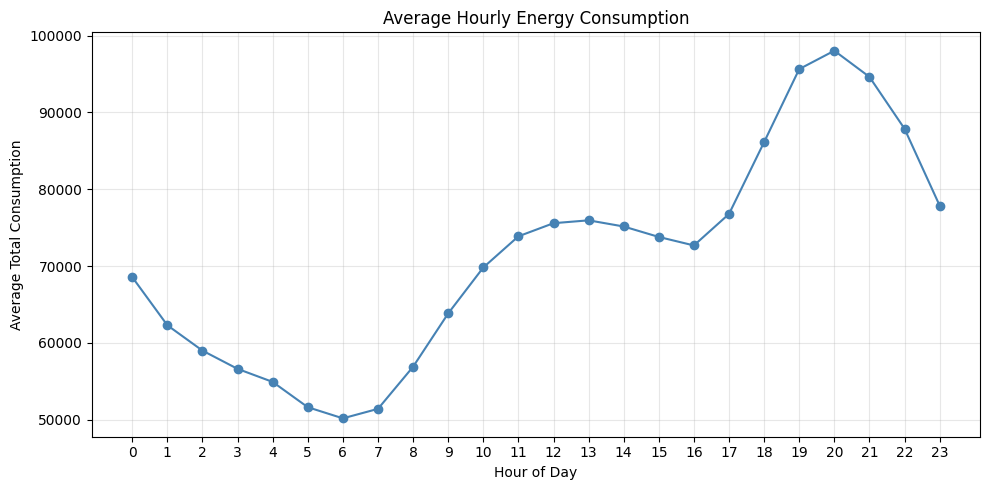

In [201]:
#Step 14: Visualize Hourly Consumption Trend

import matplotlib.pyplot as plt

hourly_pd = hourly_consumption.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(hourly_pd["Hour"], hourly_pd["Avg_Consumption"], marker="o", color="steelblue")
plt.title("Average Hourly Energy Consumption")
plt.xlabel("Hour of Day")
plt.ylabel("Average Total Consumption")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

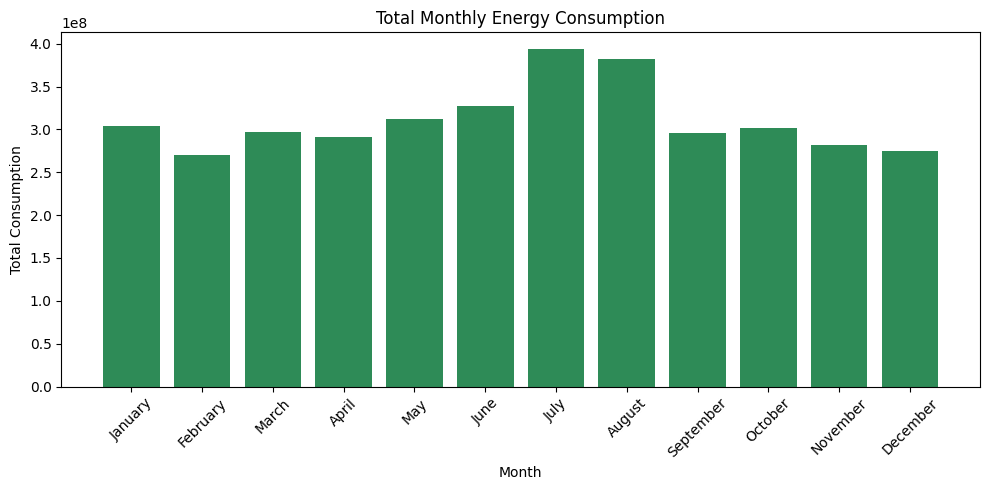

In [202]:
#Step 15: Visualize Monthly Consumption Report

monthly_pd = monthly_report.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(monthly_pd["MonthName"], monthly_pd["Total_Monthly_Consumption"], color="seagreen")
plt.title("Total Monthly Energy Consumption")
plt.xlabel("Month")
plt.ylabel("Total Consumption")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Q6. ETL Pipeline

In [203]:
#Step 1: EXTRACT - Ingest Raw Smart Meter & Weather Data

def extract_raw_data(spark, path):
    """Extract raw energy consumption data from source CSV."""
    raw_df = spark.read.csv(path, header=True, inferSchema=True)
    print(f"Extracted {raw_df.count()} raw records from {path}")
    return raw_df

raw_data = extract_raw_data(spark, "powerconsumption.csv")
raw_data.printSchema()

Extracted 52416 raw records from powerconsumption.csv
root
 |-- Datetime: string (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Humidity: double (nullable = true)
 |-- WindSpeed: double (nullable = true)
 |-- GeneralDiffuseFlows: double (nullable = true)
 |-- DiffuseFlows: double (nullable = true)
 |-- PowerConsumption_Zone1: double (nullable = true)
 |-- PowerConsumption_Zone2: double (nullable = true)
 |-- PowerConsumption_Zone3: double (nullable = true)



In [204]:
#Step 2: TRANSFORM - Clean & Standardize the Raw Data

from pyspark.sql.functions import col, trim, try_to_timestamp, lit
from pyspark.sql.types import TimestampType

def clean_data(raw_df):
    """Cast datetime, drop duplicates, and drop rows with nulls in key columns."""
    cleaned = raw_df.withColumn(
        "Datetime",
        try_to_timestamp(trim(col("Datetime")), lit("M/d/yyyy H:mm")).cast(TimestampType())
    ).dropDuplicates().dropna(
        subset=["Datetime", "Temperature", "Humidity", "WindSpeed",
                "PowerConsumption_Zone1", "PowerConsumption_Zone2", "PowerConsumption_Zone3"]
    )
    return cleaned

cleaned_data = clean_data(raw_data)
print(f"Records after cleaning: {cleaned_data.count()}")
cleaned_data.show(5)

Records after cleaning: 52416
+-------------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+
|           Datetime|Temperature|Humidity|WindSpeed|GeneralDiffuseFlows|DiffuseFlows|PowerConsumption_Zone1|PowerConsumption_Zone2|PowerConsumption_Zone3|
+-------------------+-----------+--------+---------+-------------------+------------+----------------------+----------------------+----------------------+
|2017-01-05 21:10:00|       11.0|    79.7|    0.088|              0.077|       0.108|           41577.72152|           26330.69909|           25451.56627|
|2017-01-07 02:00:00|      11.32|    78.9|     0.09|              0.051|        0.13|            23027.8481|           14753.79939|           14856.86747|
|2017-01-08 19:50:00|      15.17|    74.6|    0.072|              0.048|       0.089|            41796.4557|           24656.53495|           25729.15663|
|2017-01-09 10:40:00|      16.06|   59.9

In [205]:
#Step 3: TRANSFORM - Feature Engineering (Time Attributes & Derived Metrics)

from pyspark.sql.functions import hour, dayofmonth, month, year, date_format

def enrich_data(cleaned_df):
    """Add time-based features and total/derived consumption metrics."""
    enriched = cleaned_df.withColumn("Hour", hour("Datetime")) \
        .withColumn("Day", dayofmonth("Datetime")) \
        .withColumn("Month", month("Datetime")) \
        .withColumn("Year", year("Datetime")) \
        .withColumn("MonthName", date_format("Datetime", "MMMM")) \
        .withColumn(
            "Total_Consumption",
            col("PowerConsumption_Zone1") + col("PowerConsumption_Zone2") + col("PowerConsumption_Zone3")
        )
    return enriched

enriched_data = enrich_data(cleaned_data)
enriched_data.select("Datetime", "Hour", "Month", "Year", "Total_Consumption").show(5)

+-------------------+----+-----+----+-----------------+
|           Datetime|Hour|Month|Year|Total_Consumption|
+-------------------+----+-----+----+-----------------+
|2017-01-05 21:10:00|  21|    1|2017|      93359.98688|
|2017-01-07 02:00:00|   2|    1|2017|      52638.51496|
|2017-01-08 19:50:00|  19|    1|2017|92182.14727999999|
|2017-01-09 10:40:00|  10|    1|2017|66782.60506999999|
|2017-01-10 20:30:00|  20|    1|2017|      94980.43881|
+-------------------+----+-----+----+-----------------+
only showing top 5 rows


In [206]:
#Step 4: TRANSFORM - Split into Smart Meter (Fact) and Weather (Dimension) Tables

def split_datasets(enriched_df):
    """Separate the enriched dataset into a smart-meter fact table and a weather dimension table."""
    smart_meter_fact = enriched_df.select(
        "Datetime", "Year", "Month", "Day", "Hour",
        "PowerConsumption_Zone1", "PowerConsumption_Zone2", "PowerConsumption_Zone3",
        "Total_Consumption"
    )

    weather_dim = enriched_df.select(
        "Datetime", "Temperature", "Humidity", "WindSpeed",
        "GeneralDiffuseFlows", "DiffuseFlows"
    )

    return smart_meter_fact, weather_dim

smart_meter_fact, weather_dim = split_datasets(enriched_data)
smart_meter_fact.show(5)
weather_dim.show(5)

+-------------------+----+-----+---+----+----------------------+----------------------+----------------------+-----------------+
|           Datetime|Year|Month|Day|Hour|PowerConsumption_Zone1|PowerConsumption_Zone2|PowerConsumption_Zone3|Total_Consumption|
+-------------------+----+-----+---+----+----------------------+----------------------+----------------------+-----------------+
|2017-01-05 21:10:00|2017|    1|  5|  21|           41577.72152|           26330.69909|           25451.56627|      93359.98688|
|2017-01-07 02:00:00|2017|    1|  7|   2|            23027.8481|           14753.79939|           14856.86747|      52638.51496|
|2017-01-08 19:50:00|2017|    1|  8|  19|            41796.4557|           24656.53495|           25729.15663|92182.14727999999|
|2017-01-09 10:40:00|2017|    1|  9|  10|           32105.31646|           19779.93921|            14897.3494|66782.60506999999|
|2017-01-10 20:30:00|2017|    1| 10|  20|           43376.20253|           26308.81459|          

In [207]:
#Step 5: TRANSFORM - Data Quality Checks

def data_quality_report(raw_df, final_df):
    """Compare record counts and check for remaining nulls."""
    raw_count = raw_df.count()
    final_count = final_df.count()
    dropped = raw_count - final_count

    null_counts = final_df.select(
        [ (col(c).isNull().cast("int")).alias(c) for c in final_df.columns ]
    ).groupBy().sum().collect()[0].asDict()

    print(f"Raw records: {raw_count}")
    print(f"Final records: {final_count}")
    print(f"Records dropped during cleaning: {dropped}")
    print("Null counts per column:")
    for k, v in null_counts.items():
        if v and v > 0:
            print(f"  {k}: {v}")
    print("Data quality check passed - no critical nulls found" if dropped >= 0 else "Check failed")

data_quality_report(raw_data, enriched_data)

Raw records: 52416
Final records: 52416
Records dropped during cleaning: 0
Null counts per column:
Data quality check passed - no critical nulls found


In [208]:
#Step 6: LOAD - Persist Smart Meter Fact Table (Partitioned by Year & Month)

def load_to_parquet(df, output_path, partition_cols=None):
    """Write a DataFrame to Parquet, optionally partitioned."""
    writer = df.write.mode("overwrite")
    if partition_cols:
        writer = writer.partitionBy(*partition_cols)
    writer.parquet(output_path)
    print(f"Loaded data to {output_path}")

load_to_parquet(smart_meter_fact, "output/smart_meter_fact", partition_cols=["Year", "Month"])

Loaded data to output/smart_meter_fact


In [209]:
#Step 7: LOAD - Persist Weather Dimension Table

load_to_parquet(weather_dim, "output/weather_dim")

Loaded data to output/weather_dim


In [210]:
#Step 8: LOAD - Verify Persisted Data

verify_fact = spark.read.parquet("output/smart_meter_fact")
verify_weather = spark.read.parquet("output/weather_dim")

print(f"Smart meter fact table records: {verify_fact.count()}")
print(f"Weather dimension table records: {verify_weather.count()}")
verify_fact.show(5)

Smart meter fact table records: 52416
Weather dimension table records: 52416
+-------------------+---+----+----------------------+----------------------+----------------------+------------------+----+-----+
|           Datetime|Day|Hour|PowerConsumption_Zone1|PowerConsumption_Zone2|PowerConsumption_Zone3| Total_Consumption|Year|Month|
+-------------------+---+----+----------------------+----------------------+----------------------+------------------+----+-----+
|2017-08-01 04:20:00|  1|   4|           30442.97447|           20010.98205|           21830.21944|       72284.17596|2017|    8|
|2017-08-01 20:10:00|  1|  20|           49685.59378|           33255.33263|           38965.76803|121906.69443999999|2017|    8|
|2017-08-03 20:40:00|  3|  20|           49442.66371|           36201.47835|           37960.62696|      123604.76902|2017|    8|
|2017-08-04 15:10:00|  4|  15|           41342.86349|           29799.78881|           26783.69906|       97926.35136|2017|    8|
|2017-08-06 0

In [211]:
#Step 9: Orchestrate Full ETL Pipeline (Extract -> Transform -> Load)

import time

def run_etl_pipeline(spark, source_path):
    """End-to-end ETL pipeline for smart meter and weather data."""
    start = time.time()

    print("=== EXTRACT ===")
    raw = extract_raw_data(spark, source_path)

    print("=== TRANSFORM ===")
    cleaned = clean_data(raw)
    enriched = enrich_data(cleaned)
    fact, dim = split_datasets(enriched)
    data_quality_report(raw, enriched)

    print("=== LOAD ===")
    load_to_parquet(fact, "output/smart_meter_fact", partition_cols=["Year", "Month"])
    load_to_parquet(dim, "output/weather_dim")

    elapsed = time.time() - start
    print(f"ETL pipeline completed in {elapsed:.2f} seconds")
    return fact, dim

fact_table, weather_table = run_etl_pipeline(spark, "powerconsumption.csv")

=== EXTRACT ===
Extracted 52416 raw records from powerconsumption.csv
=== TRANSFORM ===
Raw records: 52416
Final records: 52416
Records dropped during cleaning: 0
Null counts per column:
Data quality check passed - no critical nulls found
=== LOAD ===
Loaded data to output/smart_meter_fact
Loaded data to output/weather_dim
ETL pipeline completed in 5.60 seconds


Q7. Machine Learning

In [213]:
#Step 1: Prepare Feature Vector for Demand Prediction

from pyspark.sql.functions import col, when, abs as _abs
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

feature_cols = ["Temperature", "Humidity", "WindSpeed", "GeneralDiffuseFlows", "DiffuseFlows", "Hour", "Month"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
ml_data = assembler.transform(df).select("Datetime", "features", col("Total_Consumption").alias("label"))
ml_data.show(5, truncate=False)

+-------------------+----------------------------------------+-----------------+
|Datetime           |features                                |label            |
+-------------------+----------------------------------------+-----------------+
|2017-01-01 22:30:00|[12.64,66.77,0.072,0.044,0.141,22.0,1.0]|79736.44857000001|
|2017-01-03 22:10:00|[9.0,83.9,0.072,0.051,0.108,22.0,1.0]   |85895.93338999999|
|2017-01-05 13:30:00|[16.7,59.2,0.082,494.8,58.49,13.0,1.0]  |72418.13177      |
|2017-01-06 12:30:00|[14.7,66.08,0.087,235.1,202.6,12.0,1.0] |70032.91266999999|
|2017-01-07 06:20:00|[8.61,84.6,0.086,0.066,0.167,6.0,1.0]   |54291.77784      |
+-------------------+----------------------------------------+-----------------+
only showing top 5 rows


In [214]:
#Step 2: Train-Test Split
train_data, test_data = ml_data.randomSplit([0.8, 0.2], seed=42)
print(f"Training records: {train_data.count()}")
print(f"Testing records: {test_data.count()}")

Training records: 42060
Testing records: 10356


In [215]:
#Step 3: Train multiple regression models for comparison
candidate_models = [
    ("LinearRegression", LinearRegression(featuresCol="features", labelCol="label", maxIter=100, regParam=0.1)),
    ("DecisionTree", DecisionTreeRegressor(featuresCol="features", labelCol="label", maxDepth=8)),
    ("RandomForest", RandomForestRegressor(featuresCol="features", labelCol="label", numTrees=50, maxDepth=8, seed=42)),
    ("GradientBoostedTrees", GBTRegressor(featuresCol="features", labelCol="label", maxIter=50, maxDepth=5, seed=42))
]

evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")

fitted_models = {}
model_metrics = []

for name, estimator in candidate_models:
    model = estimator.fit(train_data)
    fitted_models[name] = model
    preds = model.transform(test_data)
    rmse = evaluator_rmse.evaluate(preds)
    mae = evaluator_mae.evaluate(preds)
    r2 = evaluator_r2.evaluate(preds)
    model_metrics.append((name, rmse, mae, r2))
    print(f"{name}: RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.4f}")

metrics_df = spark.createDataFrame(
    [(name, rmse, mae, r2) for name, rmse, mae, r2 in model_metrics],
    ["model_name", "rmse", "mae", "r2"]
).orderBy("rmse")
print("\nModel comparison table:")
metrics_df.show(truncate=False)

best_model_name = metrics_df.first()["model_name"]
best_model = fitted_models[best_model_name]
print(f"\nBest model selected by lowest RMSE: {best_model_name}")

LinearRegression: RMSE=10457.17, MAE=8204.35, R2=0.6213
DecisionTree: RMSE=4793.36, MAE=3439.97, R2=0.9204
RandomForest: RMSE=4754.51, MAE=3489.75, R2=0.9217
GradientBoostedTrees: RMSE=4167.77, MAE=3055.99, R2=0.9398

Model comparison table:
+--------------------+------------------+------------------+------------------+
|model_name          |rmse              |mae               |r2                |
+--------------------+------------------+------------------+------------------+
|GradientBoostedTrees|4167.771178636226 |3055.994188583312 |0.939844527135061 |
|RandomForest        |4754.511603707984 |3489.7451720953436|0.9217148777317643|
|DecisionTree        |4793.363508108393 |3439.9716429453633|0.9204302229078232|
|LinearRegression    |10457.166039697766|8204.35392987402  |0.6212999010858351|
+--------------------+------------------+------------------+------------------+


Best model selected by lowest RMSE: GradientBoostedTrees


In [216]:
#Step 4: Evaluate the selected best model and inspect predictions
best_predictions = best_model.transform(test_data)
print(f"Selected best model performance -> RMSE: {evaluator_rmse.evaluate(best_predictions):.2f}, MAE: {evaluator_mae.evaluate(best_predictions):.2f}, R2: {evaluator_r2.evaluate(best_predictions):.4f}")
best_predictions.select("Datetime", "label", "prediction").show(10, truncate=False)

Selected best model performance -> RMSE: 4167.77, MAE: 3055.99, R2: 0.9398
+-------------------+------------------+------------------+
|Datetime           |label             |prediction        |
+-------------------+------------------+------------------+
|2017-01-01 00:30:00|65489.23208999999 |62221.163371951014|
|2017-01-01 02:00:00|54290.73952       |51283.15139222928 |
|2017-01-01 02:20:00|52186.32556       |51158.654441129656|
|2017-01-01 03:40:00|48337.87191       |49860.50977891387 |
|2017-01-01 05:00:00|47592.719260000005|50848.530046300366|
|2017-01-01 06:20:00|50028.492419999995|50880.02168847515 |
|2017-01-01 08:30:00|42962.05861       |50982.01183517029 |
|2017-01-01 10:30:00|58220.10518       |64378.04401542306 |
|2017-01-01 14:20:00|65084.69718       |70566.7931051678  |
|2017-01-01 14:50:00|64336.45427       |70421.69115951806 |
+-------------------+------------------+------------------+
only showing top 10 rows


In [217]:
#Step 5: Understand the selected model
if hasattr(best_model, "featureImportances"):
    importances = best_model.featureImportances.toArray()
    print("\nFeature importances for the selected model:")
    for feature, importance in sorted(zip(feature_cols, importances), key=lambda x: -x[1]):
        print(f"  {feature}: {importance:.4f}")
elif hasattr(best_model, "coefficients"):
    print("\nLinear model coefficients for the selected model:")
    for feature, coef in zip(feature_cols, best_model.coefficients):
        print(f"  {feature}: {coef:.4f}")
else:
    print("\nSelected model does not expose feature importances or coefficients.")


Feature importances for the selected model:
  Hour: 0.5649
  Temperature: 0.1850
  Month: 0.1497
  WindSpeed: 0.0367
  GeneralDiffuseFlows: 0.0294
  Humidity: 0.0178
  DiffuseFlows: 0.0164



Mean absolute residual: 3055.99
Std deviation of residual: 2834.08
Anomaly threshold: 11558.22
Detected 185 anomalies out of 10356 test records (1.79%)
+-------------------+------------------+-----------------+------------------+
|Datetime           |label             |prediction       |abs_residual      |
+-------------------+------------------+-----------------+------------------+
|2017-06-25 03:00:00|84998.64261       |62198.10194370254|22800.540666297456|
|2017-08-31 02:00:00|59322.711449999995|81152.77583387424|21830.064383874247|
|2017-05-29 18:50:00|89779.21263       |67980.01843951242|21799.19419048757 |
|2017-06-27 19:10:00|71588.05365       |93173.46620239693|21585.412552396927|
|2017-05-28 18:50:00|89422.39886       |67876.4413998647 |21545.957460135294|
|2017-04-02 18:20:00|63054.34654       |84521.5233158523 |21467.176775852306|
|2017-04-30 19:00:00|74416.82521       |95108.18919666909|20691.363986669094|
|2017-05-11 02:30:00|55621.989180000004|76282.90540596745|20660.916

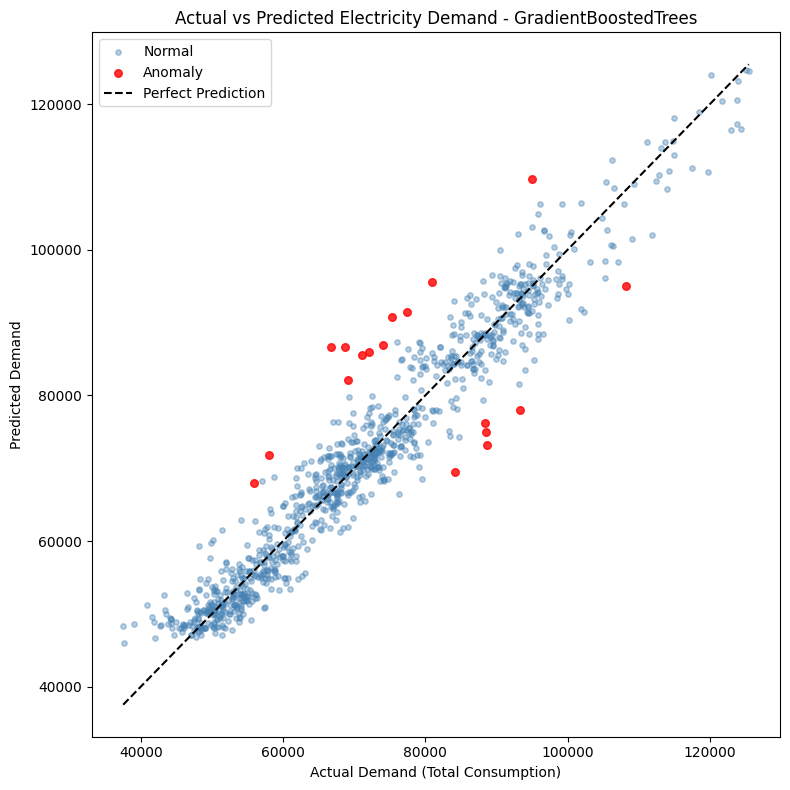

In [218]:
#Step 6: Detect anomalies using the best model
best_predictions = best_predictions.withColumn("residual", col("label") - col("prediction")) \
    .withColumn("abs_residual", _abs(col("label") - col("prediction")))

residual_stats = best_predictions.select("abs_residual").summary("mean", "stddev").collect()
mean_residual = float(residual_stats[0]["abs_residual"])
std_residual = float(residual_stats[1]["abs_residual"])
anomaly_threshold = mean_residual + 3 * std_residual
print(f"\nMean absolute residual: {mean_residual:.2f}")
print(f"Std deviation of residual: {std_residual:.2f}")
print(f"Anomaly threshold: {anomaly_threshold:.2f}")

anomalies = best_predictions.withColumn(
    "is_anomaly",
    when(col("abs_residual") > anomaly_threshold, True).otherwise(False)
)

anomaly_count = anomalies.filter(col("is_anomaly") == True).count()
total_count = anomalies.count()
print(f"Detected {anomaly_count} anomalies out of {total_count} test records ({(anomaly_count / total_count) * 100:.2f}%)")

anomalies.filter(col("is_anomaly") == True) \
    .select("Datetime", "label", "prediction", "abs_residual") \
    .orderBy(col("abs_residual").desc()) \
    .show(10, truncate=False)

import matplotlib.pyplot as plt
sample_pd = anomalies.select("label", "prediction", "is_anomaly").sample(fraction=0.1, seed=42).toPandas()
normal_pts = sample_pd[sample_pd["is_anomaly"] == False]
anomaly_pts = sample_pd[sample_pd["is_anomaly"] == True]

plt.figure(figsize=(8, 8))
plt.scatter(normal_pts["label"], normal_pts["prediction"], alpha=0.4, label="Normal", color="steelblue", s=15)
plt.scatter(anomaly_pts["label"], anomaly_pts["prediction"], alpha=0.8, label="Anomaly", color="red", s=30)
plt.plot([sample_pd["label"].min(), sample_pd["label"].max()],
         [sample_pd["label"].min(), sample_pd["label"].max()], "k--", label="Perfect Prediction")
plt.xlabel("Actual Demand (Total Consumption)")
plt.ylabel("Predicted Demand")
plt.title(f"Actual vs Predicted Electricity Demand - {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()